# <span style="color:rgb(213,80,0)">ROZWIĄZYWANIE UKŁADÓW RÓWNAŃ LINIOWYCH</span>

## Metoda rozkładu LU

Aby zobrazować zalety metody LU pod względem rozwiązywania powtarzalnych zadań różniących się między sobą tylko wektorami ***b***, poniżej przedstawiono kod rozwiązujący losowo generowany problem o rosnącym rozmiarze.

Pokazywana jest estymata złożoności czasowej w postaci czasu wykonania obliczeń. Dla porównania, z metodą eliminacji Gaussa (która za każdym razem przekształca macierz ***A*** i wektor ***b***), kolorem niebieskim zaznaczono te same wyniki dla eliminacji Gaussa.

- **Ciągłą linią czerwoną** — estymata złożoności bez kroku rozkładu (same podstawianie w przód i wstecz), odpowiada sytuacji, kiedy macierz ***A*** jest stała, a zmienia się tylko ***b***
- **Czerwoną linią przerywaną** — estymata złożoności z krokiem rozkładu LU
- **Ciągłą linią niebieską** — estymata złożoności metody Gaussa

**UWAGA!** Metoda LU (z krokiem rozkładu) i metoda Gaussa mają tę samą klasę złożoności $O\left(n^3 \right)$ — jak widać na wykresie, klasa złożoności to nie sama złożoność. Czas wykonania obliczeń przy tej samej klasie może się znacznie różnić — obie krzywe można ograniczyć wielomianem stopnia 3, ale są to różne wielomiany i różne stałe. Ma to istotny wpływ na praktyczne właściwości metody.

**UWAGA!** Poniższe obliczenia mogą trwać ~30s. Wszystkie dane używają `float64`.


In [1]:
import numpy as np
import time
from scipy.linalg import lu_factor, lu_solve

def solveUsingLUFactorization(A, b):
    time1 = time.perf_counter()
    from scipy.linalg import lu_factor, lu_solve
    lu_pivots = lu_factor(A)
    time2 = time.perf_counter()
    x = lu_solve(lu_pivots, b)
    time2end = time.perf_counter() - time2
    time1end = time.perf_counter() - time1
    error = np.linalg.norm(x - np.ones(len(b))) / np.linalg.norm(np.ones(len(b)))
    return time1end, time2end, error


def solveUsingGaussElimination(A, b):
    time1 = time.perf_counter()
    x = solveGauss(A, b)
    time1end = time.perf_counter() - time1
    error = np.linalg.norm(x - np.ones(len(b))) / np.linalg.norm(np.ones(len(b)))
    return time1end, 0, error


def solveGauss(A, b):
    A = A.copy().astype(float)
    b = b.copy().astype(float)
    s = len(A)
    # Eliminacja Gaussian
    for j in range(s - 1):
        for i in range(s - 1, j, -1):
            m = A[i, j] / A[j, j]
            A[i, :] -= m * A[j, :]
            b[i] -= m * b[j]
    # Podstawianie wsteczne
    x = np.zeros(s)
    x[s - 1] = b[s - 1] / A[s - 1, s - 1]
    for i in range(s - 2, -1, -1):
        sump = 0.0
        for j in range(s - 1, i, -1):
            sump += A[i, j] * x[j]
        x[i] = (b[i] - sump) / A[i, i]
    return x


Rozwiązywanie... (to może trwać ~30s)


Gotowe! Całkowity czas: 0.4s


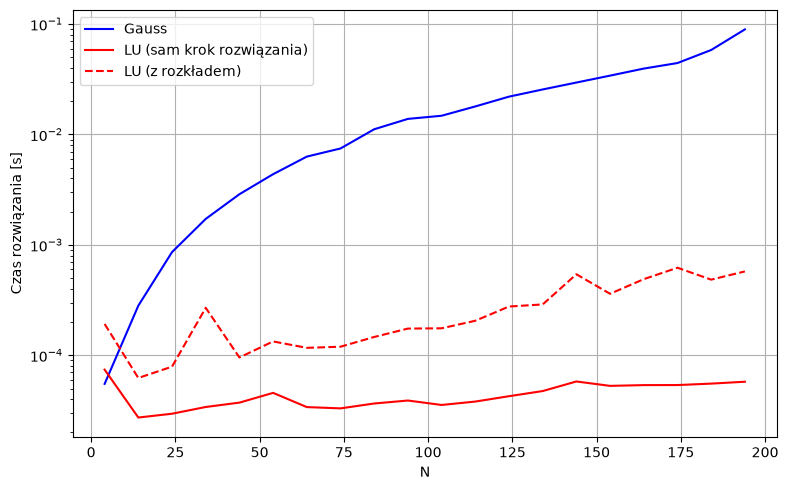

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.random.seed(42)
Nmax = 200
step = 10

zlozonoscGauss = []; zlozonoscLU = []; zlozonoscLUFull = []
sizes = []

print("Rozwiązywanie... (to może trwać ~30s)")
T0 = time.perf_counter()
for i in range(4, Nmax + 1, step):
    A = np.random.rand(i, i).astype(np.float64)
    b = A.sum(axis=1).astype(np.float64)
    gauss_all, gauss_simple, gauss_err = solveUsingGaussElimination(A, b)
    zlozonoscGauss.append(gauss_all)
    sizes.append(i)
    lu_all, lu_simple, lu_err = solveUsingLUFactorization(A, b)
    zlozonoscLU.append(lu_simple)
    zlozonoscLUFull.append(lu_all)
    if i % 10 == 0:
        elapsed = time.perf_counter() - T0
        print(f"  N={i:4d}/{Nmax}  ({elapsed:.1f}s)")

print(f"Gotowe! Całkowity czas: {time.perf_counter()-T0:.1f}s")

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_yscale('log')
ax.plot(sizes, zlozonoscGauss, 'b', label='Gauss')
ax.plot(sizes, zlozonoscLU, 'r', label='LU (sam krok rozwiązania)')
ax.plot(sizes, zlozonoscLUFull, 'r--', label='LU (z rozkładem)')
ax.set_xlabel('N')
ax.set_ylabel('Czas rozwiązania [s]')
ax.grid(True)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Wykorzystywane funkcje

| Funkcja | Opis |
|---------|------|
| `scipy.linalg.lu_factor(A)` | Oblicza rozkład LU macierzy A z pivotowaniem |
| `scipy.linalg.lu_solve((lu, piv), b)` | Rozwiązuje układ A*x=b używając rozkładu LU |
| `np.linalg.norm(x)` | Oblicza normę euklidesową wektora |
| `time.perf_counter()` | Zwraca czas procesora o wysokiej rozdzielczości |
